In [14]:
# 1. Imports and project settings
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
FAST_MODE = True  # Change to False before final evaluation.
TRAINING_SAMPLE_SIZE = 100_000  # Used only when FAST_MODE is True.

PROJECT_ROOT = Path.cwd().resolve()
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
MODEL_DIR = ARTIFACT_DIR / "models"
PLOT_DIR = ARTIFACT_DIR / "plots"
REPORT_DIR = ARTIFACT_DIR / "reports"
for folder in [MODEL_DIR, PLOT_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

dataset_candidates = [
    PROJECT_ROOT / "data" / "raw" / "emi_prediction_dataset.csv",
    Path.home() / "Downloads" / "emi_prediction_dataset.csv",
]
RAW_DATA_PATH = next((path for path in dataset_candidates if path.exists()), None)
if RAW_DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Place emi_prediction_dataset.csv in data/raw/."
    )

print(f"Using dataset: {RAW_DATA_PATH}")
print(f"Fast mode: {FAST_MODE}")


Using dataset: C:\Users\jenis\Downloads\emi_prediction_dataset.csv
Fast mode: True


## 2. Load the real dataset

We read the actual CSV before making any assumptions about its columns or values.


In [15]:
df_raw = pd.read_csv(RAW_DATA_PATH, low_memory=False)

print(f"Rows and columns: {df_raw.shape}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
display(df_raw.head())
display(pd.DataFrame({"column": df_raw.columns, "dtype": df_raw.dtypes.astype(str)}))


Rows and columns: (404800, 27)
Memory usage: 344.83 MB


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


,column,dtype
age,age,object
gender,gender,object
marital_status,marital_status,object
education,education,object
monthly_salary,monthly_salary,object
employment_type,employment_type,object
years_of_employment,years_of_employment,float64
company_type,company_type,object
house_type,house_type,object
monthly_rent,monthly_rent,float64


## 3. Data-quality report

We count missing values and duplicates before changing anything. The report is saved so it can be shown during evaluation.


In [16]:
quality_report = pd.DataFrame(
    {
        "dtype": df_raw.dtypes.astype(str),
        "missing_count": df_raw.isna().sum(),
        "missing_percent": (df_raw.isna().mean() * 100).round(2),
        "unique_values": df_raw.nunique(dropna=False),
    }
).sort_values("missing_count", ascending=False)

duplicate_rows = int(df_raw.duplicated().sum())
print(f"Duplicate rows: {duplicate_rows:,}")
display(quality_report)
quality_report.to_csv(REPORT_DIR / "data_quality_report.csv")


Duplicate rows: 0


,dtype,missing_count,missing_percent,unique_values
monthly_rent,float64,2426,0.60,4397
bank_balance,object,2426,0.60,12262
credit_score,float64,2420,0.60,428
education,object,2404,0.59,5
emergency_fund,float64,2351,0.58,5487
marital_status,object,0,0.00,2
monthly_salary,object,0,0.00,13662
years_of_employment,float64,0,0.00,356
gender,object,0,0.00,8
employment_type,object,0,0.00,3


## 4. Cleaning functions

The real CSV contains malformed numeric text such as `18000.0.0`, mixed gender labels, and missing values. We repair values carefully:

- Numeric conversion changes invalid text to missing values instead of guessing.
- Out-of-range age and credit score values become missing values.
- The machine-learning pipeline later fills missing numeric values with the training-set median and missing categories with the most frequent training category.
- No duplicate rows are removed automatically because this dataset has no exact duplicates.


In [17]:
NUMERIC_COLUMNS = [
    "age", "monthly_salary", "years_of_employment", "monthly_rent",
    "family_size", "dependents", "school_fees", "college_fees",
    "travel_expenses", "groceries_utilities", "other_monthly_expenses",
    "current_emi_amount", "credit_score", "bank_balance", "emergency_fund",
    "requested_amount", "requested_tenure", "max_monthly_emi",
]
CATEGORICAL_COLUMNS = [
    "gender", "marital_status", "education", "employment_type",
    "company_type", "house_type", "existing_loans", "emi_scenario",
    "emi_eligibility",
]

def normalise_numeric(series: pd.Series) -> pd.Series:
    # Turn normal numbers and malformed values like 18000.0.0 into numbers.
    text = series.astype("string").str.strip()
    text = text.str.replace(r"^(-?\d+(?:\.\d+)?)\.0$", r"\1", regex=True)
    return pd.to_numeric(text, errors="coerce")


def clean_data(frame: pd.DataFrame) -> pd.DataFrame:
    # Return a cleaned copy; the original dataframe is never changed.
    result = frame.copy()

    for column in NUMERIC_COLUMNS:
        result[column] = normalise_numeric(result[column])

    for column in CATEGORICAL_COLUMNS:
        # Keep standard Python objects and np.nan so SimpleImputer can process them.
        result[column] = result[column].astype(object)
        result[column] = result[column].map(
            lambda value: value.strip() if isinstance(value, str) else value
        )
        result[column] = result[column].where(result[column].notna(), np.nan)

    gender_map = {
        "M": "Male", "MALE": "Male", "male": "Male", "Male": "Male",
        "F": "Female", "FEMALE": "Female", "female": "Female", "Female": "Female",
    }
    result["gender"] = result["gender"].replace(gender_map)

    result.loc[~result["age"].between(18, 100), "age"] = np.nan
    result.loc[~result["credit_score"].between(300, 850), "credit_score"] = np.nan
    result.loc[result["monthly_salary"] <= 0, "monthly_salary"] = np.nan
    result.loc[result["requested_amount"] <= 0, "requested_amount"] = np.nan
    result.loc[result["requested_tenure"] <= 0, "requested_tenure"] = np.nan
    result.loc[result["dependents"] > result["family_size"], "dependents"] = np.nan
    return result


df_clean = clean_data(df_raw)
cleaned_missing = pd.DataFrame(
    {
        "before_cleaning": df_raw.isna().sum(),
        "after_cleaning": df_clean.isna().sum(),
    }
)
display(cleaned_missing[cleaned_missing.sum(axis=1) > 0])
print("Gender values after normalization:")
display(df_clean["gender"].value_counts(dropna=False))


,before_cleaning,after_cleaning
education,2404,2404
monthly_salary,0,3
monthly_rent,2426,2426
credit_score,2420,7196
bank_balance,2426,2447
emergency_fund,2351,2351


Gender values after normalization:


gender
Male      242950
Female    161850
Name: count, dtype: int64

## 5. Financial feature engineering

These features use only information available before a lending decision. The requested-payment proxy is **not** a bank EMI because the dataset has no interest-rate column.


In [18]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    # Avoid division by zero and keep undefined values missing.
    return numerator / denominator.mask(denominator == 0)


def add_financial_features(frame: pd.DataFrame) -> pd.DataFrame:
    # Create transparent financial ratios for the models.
    result = frame.copy()
    expense_columns = [
        "monthly_rent", "school_fees", "college_fees", "travel_expenses",
        "groceries_utilities", "other_monthly_expenses",
    ]
    result["total_monthly_expenses"] = result[expense_columns].sum(axis=1)
    result["annual_income"] = result["monthly_salary"] * 12
    result["expense_to_income_ratio"] = safe_divide(
        result["total_monthly_expenses"], result["monthly_salary"]
    )
    result["existing_emi_burden"] = safe_divide(
        result["current_emi_amount"], result["monthly_salary"]
    )
    result["disposable_income"] = (
        result["monthly_salary"] - result["total_monthly_expenses"] - result["current_emi_amount"]
    )
    result["loan_to_income_ratio"] = safe_divide(result["requested_amount"], result["annual_income"])
    result["emergency_fund_coverage"] = safe_divide(
        result["emergency_fund"], result["total_monthly_expenses"]
    )
    result["balance_to_income_ratio"] = safe_divide(
        result["bank_balance"], result["monthly_salary"]
    )
    result["dependent_burden"] = safe_divide(result["dependents"], result["family_size"])
    result["requested_payment_proxy"] = safe_divide(
        result["requested_amount"], result["requested_tenure"]
    )
    result["financial_cushion"] = (
        result["disposable_income"] - result["requested_payment_proxy"]
    )
    return result


df_features = add_financial_features(df_clean)
TARGET_CLASSIFICATION = "emi_eligibility"
TARGET_REGRESSION = "max_monthly_emi"
feature_columns = [
    column for column in df_features.columns
    if column not in [TARGET_CLASSIFICATION, TARGET_REGRESSION]
]

print(f"Number of model input features after engineering: {len(feature_columns)}")
display(df_features[["total_monthly_expenses", "disposable_income", "financial_cushion"]].head())


Number of model input features after engineering: 36


,total_monthly_expenses,disposable_income,financial_cushion
0,59900,-1000.0,-57666.666667
1,15400,2000.0,-4736.842105
2,35600,50500.0,31375.0
3,37400,29400.0,25737.349398
4,58600,-1300.0,-37300.0


## 6. Exploratory data analysis

Each chart answers a simple business question: What is the eligibility distribution? How do scenarios differ? Is maximum EMI related to salary?


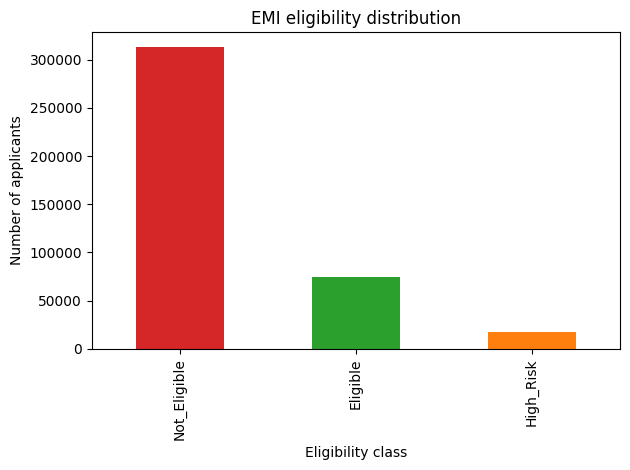

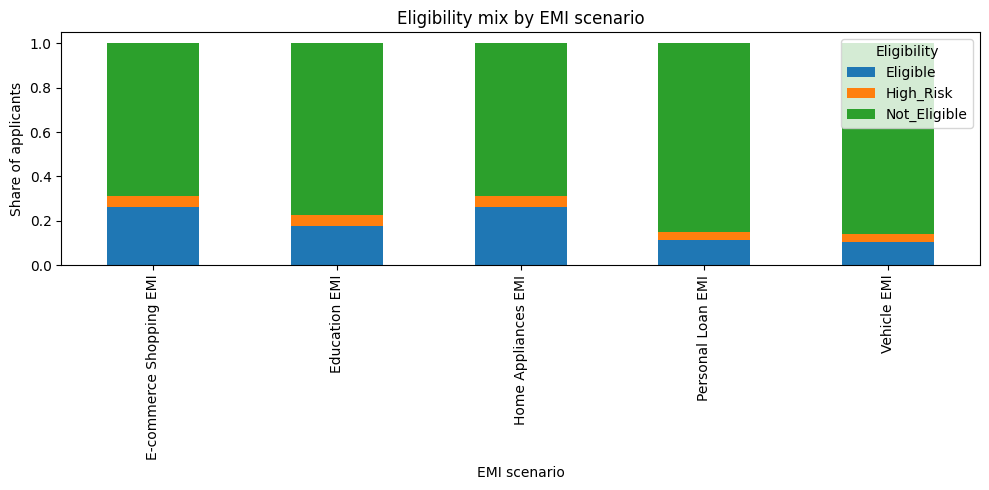

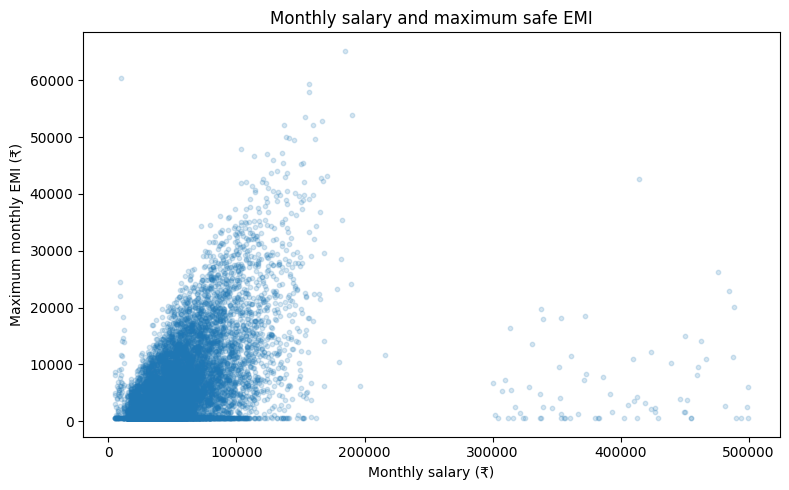

In [19]:
# Eligibility class distribution
class_counts = df_features[TARGET_CLASSIFICATION].value_counts()
ax = class_counts.plot(kind="bar", color=["#d62728", "#2ca02c", "#ff7f0e"])
ax.set_title("EMI eligibility distribution")
ax.set_xlabel("Eligibility class")
ax.set_ylabel("Number of applicants")
plt.tight_layout()
plt.savefig(PLOT_DIR / "eligibility_distribution.png", dpi=150)
plt.show()

# Eligibility by EMI scenario
scenario_table = pd.crosstab(
    df_features["emi_scenario"], df_features[TARGET_CLASSIFICATION], normalize="index"
)
scenario_table.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Eligibility mix by EMI scenario")
plt.ylabel("Share of applicants")
plt.xlabel("EMI scenario")
plt.legend(title="Eligibility")
plt.tight_layout()
plt.savefig(PLOT_DIR / "eligibility_by_scenario.png", dpi=150)
plt.show()

# A sample is enough for a readable scatter plot.
plot_sample = df_features.sample(n=min(10_000, len(df_features)), random_state=RANDOM_STATE)
plt.figure(figsize=(8, 5))
plt.scatter(plot_sample["monthly_salary"], plot_sample[TARGET_REGRESSION], alpha=0.18, s=10)
plt.title("Monthly salary and maximum safe EMI")
plt.xlabel("Monthly salary (₹)")
plt.ylabel("Maximum monthly EMI (₹)")
plt.tight_layout()
plt.savefig(PLOT_DIR / "salary_vs_max_emi.png", dpi=150)
plt.show()


## 7. Train, validation, and test split

The test set is isolated. We compare models on the validation set, choose the winners there, and report the selected models once on the untouched test set.


In [20]:
model_data = df_features.dropna(subset=[TARGET_CLASSIFICATION, TARGET_REGRESSION]).copy()

train_data, remaining_data = train_test_split(
    model_data,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=model_data[TARGET_CLASSIFICATION],
)
validation_data, test_data = train_test_split(
    remaining_data,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=remaining_data[TARGET_CLASSIFICATION],
)

if FAST_MODE and len(train_data) > TRAINING_SAMPLE_SIZE:
    train_data, _ = train_test_split(
        train_data,
        train_size=TRAINING_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=train_data[TARGET_CLASSIFICATION],
    )

X_train = train_data[feature_columns]
X_valid = validation_data[feature_columns]
X_test = test_data[feature_columns]

label_encoder = LabelEncoder()
y_train_class = label_encoder.fit_transform(train_data[TARGET_CLASSIFICATION])
y_valid_class = label_encoder.transform(validation_data[TARGET_CLASSIFICATION])
y_test_class = label_encoder.transform(test_data[TARGET_CLASSIFICATION])
y_train_reg = train_data[TARGET_REGRESSION]
y_valid_reg = validation_data[TARGET_REGRESSION]
y_test_reg = test_data[TARGET_REGRESSION]

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = [column for column in feature_columns if column not in numeric_features]

print(f"Train rows used: {len(X_train):,}")
print(f"Validation rows: {len(X_valid):,}")
print(f"Test rows: {len(X_test):,}")
print("Class labels:", list(label_encoder.classes_))


Train rows used: 100,000
Validation rows: 60,720
Test rows: 60,720
Class labels: ['Eligible', 'High_Risk', 'Not_Eligible']


## 8. Common preprocessing pipeline

A `ColumnTransformer` applies the same preprocessing to every model. It learns medians and categories from the training data only, which prevents train-test leakage.


In [21]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)


## 9. Helper functions for evaluation and MLflow

Macro F1 treats each eligibility class equally. RMSE gives more weight to large EMI prediction errors. The project uses validation metrics for selection, not the test set.


In [22]:
def classification_metrics(y_true, y_pred, y_probability) -> dict:
    # Calculate common multiclass classification metrics.
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    try:
        metrics["roc_auc_ovr"] = roc_auc_score(
            y_true, y_probability, multi_class="ovr", average="macro"
        )
    except ValueError:
        metrics["roc_auc_ovr"] = np.nan
    return metrics


def regression_metrics(y_true, y_pred) -> dict:
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": root_mean_squared_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "mape": mean_absolute_percentage_error(y_true, y_pred),
    }


MLFLOW_TRACKING_URI = f"sqlite:///{(PROJECT_ROOT / 'mlflow.db').as_posix()}"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")


MLflow tracking URI: sqlite:///C:/Users/jenis/OneDrive/Documents/ChatGPT/EMIPredict AI - Intelligent Financial Risk/mlflow.db


## 10. Classification models

We train three different approaches:

- Logistic Regression: simple, fast, and interpretable baseline.
- Random Forest: a tree ensemble that can learn non-linear patterns.
- XGBoost: gradient boosting for stronger non-linear performance.


In [23]:
tree_count = 80 if FAST_MODE else 180
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=tree_count,
        max_depth=18,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "XGBoost Classifier": XGBClassifier(
        n_estimators=tree_count,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.80,
        colsample_bytree=0.80,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

mlflow.set_experiment("EMIPredict_Classification")
classification_rows = []
trained_classifiers = {}

for model_name, model in classification_models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    with mlflow.start_run(run_name=model_name):
        pipeline.fit(X_train, y_train_class)
        valid_prediction = pipeline.predict(X_valid)
        valid_probability = pipeline.predict_proba(X_valid)
        metrics = classification_metrics(y_valid_class, valid_prediction, valid_probability)

        mlflow.log_param("model_name", model_name)
        mlflow.log_param("fast_mode", FAST_MODE)
        mlflow.log_metrics({f"validation_{key}": float(value) for key, value in metrics.items() if pd.notna(value)})
        mlflow.sklearn.log_model(
    pipeline,
    name="model",
    serialization_format="skops",
    skops_trusted_types=[
        "numpy.dtype",
        "xgboost.core.Booster",
        "xgboost.sklearn.XGBClassifier",
    ],
)

    classification_rows.append({"model": model_name, **metrics})
    trained_classifiers[model_name] = pipeline
    print(f"Finished: {model_name}")

classification_results = pd.DataFrame(classification_rows).sort_values(
    "macro_f1", ascending=False
)
display(classification_results)


Finished: Logistic Regression
Finished: Random Forest Classifier
Finished: XGBoost Classifier


,model,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,roc_auc_ovr
2,XGBoost Classifier,0.963307,0.797782,0.956829,0.895709,0.765340,0.990580
1,Random Forest Classifier,0.942918,0.782444,0.944047,0.774740,0.790782,0.978882
0,Logistic Regression,0.912434,0.603252,0.893553,0.662462,0.617013,0.950843


## 11. Regression models

These models estimate the maximum safe monthly EMI. The model with the lowest validation RMSE is selected.


In [25]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=tree_count,
        max_depth=18,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "XGBoost Regressor": XGBRegressor(
        n_estimators=tree_count,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.80,
        colsample_bytree=0.80,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

mlflow.set_experiment("EMIPredict_Regression")
regression_rows = []
trained_regressors = {}

for model_name, model in regression_models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    with mlflow.start_run(run_name=model_name):
        pipeline.fit(X_train, y_train_reg)
        valid_prediction = pipeline.predict(X_valid)
        metrics = regression_metrics(y_valid_reg, valid_prediction)

        mlflow.log_param("model_name", model_name)
        mlflow.log_param("fast_mode", FAST_MODE)
        mlflow.log_metrics({f"validation_{key}": float(value) for key, value in metrics.items()})
        mlflow.sklearn.log_model(
    pipeline,
    name="model",
    serialization_format="skops",
    skops_trusted_types=[
        "numpy.dtype",
        "xgboost.core.Booster",
        "xgboost.sklearn.XGBRegressor",
    ],
)

    regression_rows.append({"model": model_name, **metrics})
    trained_regressors[model_name] = pipeline
    print(f"Finished: {model_name}")

regression_results = pd.DataFrame(regression_rows).sort_values("rmse")
display(regression_results)


Finished: Linear Regression
Finished: Random Forest Regressor
Finished: XGBoost Regressor


,model,mae,rmse,r2,mape
2,XGBoost Regressor,312.318257,854.053253,0.987943,0.121246
1,Random Forest Regressor,239.509291,921.213839,0.985973,0.059823
0,Linear Regression,2899.795528,4063.094091,0.727123,1.876737


## 12. Best-model selection, untouched test metrics, and saved artifacts

The notebook chooses the best classification model by validation Macro F1 and the best regression model by validation RMSE. The final test metrics are reported only after this selection.


In [26]:
best_classification_name = classification_results.iloc[0]["model"]
best_regression_name = regression_results.iloc[0]["model"]
best_classifier = trained_classifiers[best_classification_name]
best_regressor = trained_regressors[best_regression_name]

classification_test_prediction = best_classifier.predict(X_test)
classification_test_probability = best_classifier.predict_proba(X_test)
classification_test_metrics = classification_metrics(
    y_test_class, classification_test_prediction, classification_test_probability
)

regression_test_prediction = best_regressor.predict(X_test)
regression_test_metrics = regression_metrics(y_test_reg, regression_test_prediction)

print("Best classification model:", best_classification_name)
print("Test metrics:", classification_test_metrics)
print("Best regression model:", best_regression_name)
print("Test metrics:", regression_test_metrics)

classification_results.to_csv(MODEL_DIR / "classification_comparison.csv", index=False)
regression_results.to_csv(MODEL_DIR / "regression_comparison.csv", index=False)
joblib.dump(best_classifier, MODEL_DIR / "best_classification_pipeline.joblib")
joblib.dump(best_regressor, MODEL_DIR / "best_regression_pipeline.joblib")

metadata = {
    "feature_columns": feature_columns,
    "class_labels": label_encoder.classes_.tolist(),
    "best_classification_model": best_classification_name,
    "best_regression_model": best_regression_name,
    "classification_test_metrics": classification_test_metrics,
    "regression_test_metrics": regression_test_metrics,
    "fast_mode": FAST_MODE,
}
(MODEL_DIR / "model_metadata.json").write_text(
    json.dumps(metadata, indent=2, default=float), encoding="utf-8"
)


Best classification model: XGBoost Classifier
Test metrics: {'accuracy': 0.9638339920948616, 'macro_f1': 0.8015362838421088, 'weighted_f1': 0.9574885404925424, 'precision_macro': 0.8991229067948886, 'recall_macro': 0.7683193098374402, 'roc_auc_ovr': 0.9905418354215577}
Best regression model: XGBoost Regressor
Test metrics: {'mae': 310.96456607966275, 'rmse': 851.1246672621113, 'r2': 0.9879188095954845, 'mape': 0.11873036785810161}


1492

## 13. Register the selected models with MLflow

This is a local model-registry attempt. If your environment does not support a local registry, the saved Joblib files still allow the Streamlit app to work.


In [28]:
SKOPS_TRUSTED_TYPES = [
    "numpy.dtype",
    "xgboost.core.Booster",
    "xgboost.sklearn.XGBClassifier",
    "xgboost.sklearn.XGBRegressor",
]


def log_and_register_selected_model(
    model,
    experiment_name,
    registered_name,
):
    mlflow.set_experiment(experiment_name)

    with mlflow.start_run(
        run_name=f"register_{registered_name}"
    ):

        model_info = mlflow.sklearn.log_model(
            model,
            name="best_model",
            serialization_format="skops",
            skops_trusted_types=SKOPS_TRUSTED_TYPES,
        )

        try:
            registered_model = mlflow.register_model(
                model_uri=model_info.model_uri,
                name=registered_name,
            )

            print(
                f"Registered model: "
                f"{registered_name}"
            )

        except Exception as error:
            print(
                f"Registry was not created: {error}"
            )


log_and_register_selected_model(
    best_classifier,
    "EMIPredict_Classification",
    "EMIPredict_Eligibility_Model",
)
log_and_register_selected_model(
    best_regressor,
    "EMIPredict_Regression",
    "EMIPredict_Max_EMI_Model",
)


Successfully registered model 'EMIPredict_Eligibility_Model'.
Created version '1' of model 'EMIPredict_Eligibility_Model'.


Registered model: EMIPredict_Eligibility_Model
Registered model: EMIPredict_Max_EMI_Model


Successfully registered model 'EMIPredict_Max_EMI_Model'.
Created version '1' of model 'EMIPredict_Max_EMI_Model'.


## 14. Final notes for evaluation

- Start the MLflow interface with `mlflow ui` from the project folder.
- The saved files in `artifacts/models/` are used directly by `streamlit_app.py`.
- Explain that the test set was not used to choose models.
- Explain that financial ratios make the model inputs easier to discuss, but this application does not make actual lending decisions.
